# EN3160 — Assignment 01

## Intensity Transformations and Neighborhood Filtering

**Deshan W.U.**  
**230130E**

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Question 1

In [2]:
emma = cv.imread('images/emma.jpeg', cv.IMREAD_GRAYSCALE)# Import Emma image
assert emma is not None
t1 = np.linspace(0, 50, num=51).astype('uint8')# Define piecewise transformation function
t2 = np.linspace(100, 255, num=100).astype('uint8')
t3 = np.linspace(150, 255, num=105).astype('uint8')
t = np.concatenate((t1, t2, t3), axis=0).astype('uint8')# Concatenate all segments to create the transformation array
print(t.shape)

(256,)


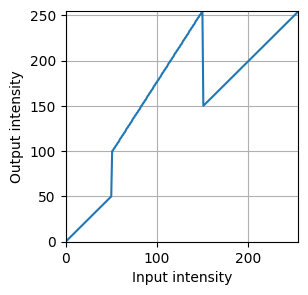

In [7]:
plt.figure(figsize=(3, 3))#Plot the transformation
plt.plot(t)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)
plt.show()

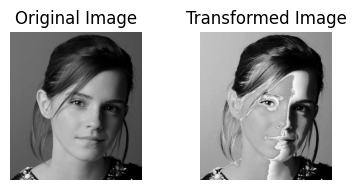

In [15]:
g = t[emma]
plt.figure(figsize=(4, 2)),plt.subplot(1, 2, 1)
plt.imshow(emma, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(g, cmap='gray', vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis('off')
plt.tight_layout()
plt.show()

### Question 2

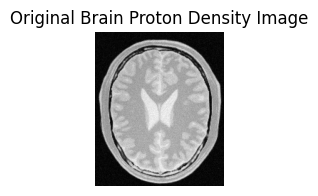

In [13]:
brain = cv.imread('images/brain.png', cv.IMREAD_GRAYSCALE)# Import brain image
assert brain is not None
plt.figure(figsize=(2, 2))# Display original image
plt.imshow(brain, cmap='gray', vmin=0, vmax=255)
plt.title("Original Brain Proton Density Image")
plt.axis("off")
plt.show()

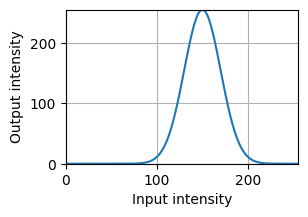

In [17]:
#a) white matter
mu = 150
sigma = 20
x = np.linspace(0, 255, 256)
t = 255 * np.exp(-((x - mu)**2) / (2 * sigma**2))
t = np.clip(t, 0, 255)# Ensure the output is in the valid range for image intensities [0, 255]
plt.figure(figsize=(3, 2))# Plot the array
plt.plot(t)
plt.xlabel("Input intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.ylabel("Output intensity")
plt.grid(True)
plt.show()

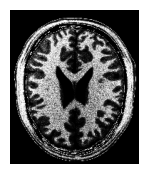

In [18]:
g = t[brain]
plt.figure(figsize=(2, 2))# Display the image
plt.imshow(g, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

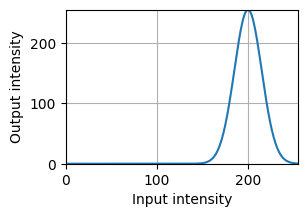

In [19]:
#b) gray matter
mu = 200
sigma = 15
x = np.linspace(0, 255, 256)
t = 255 * np.exp(-((x - mu)**2) / (2 * sigma**2))
t = np.clip(t, 0, 255)# Ensure the output is in the valid range for image intensities [0, 255]
plt.figure(figsize=(3, 2))# Plot the array
plt.plot(t)
plt.xlabel("Input intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.ylabel("Output intensity")
plt.grid(True)
plt.show()

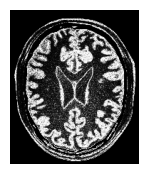

In [20]:
g = t[brain]# Apply transformation
plt.figure(figsize=(2, 2))# Display transformed image
plt.imshow(g, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### Question 3

In [21]:
girl = cv.imread('images/girl.jpeg')# Import  image
assert girl is not None
lab = cv.cvtColor(girl, cv.COLOR_BGR2LAB)
girl_rgb = cv.cvtColor(girl, cv.COLOR_BGR2RGB)
L, a, b = cv.split(lab)
L_norm = L.astype(np.float32) / 255.0

In [22]:
gamma = 0.75#Apply gamma correction
L_corrected = np.power(L_norm, gamma)
L_corrected = np.clip(L_corrected * 255,0,255).astype(np.uint8)
lab_corrected = lab.copy()
lab_corrected[:, :, 0] = L_corrected
rgb_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2RGB)

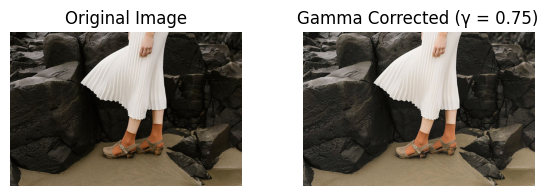

In [23]:
plt.figure(figsize=(6, 2))
plt.subplot(1, 2, 1)
plt.imshow(girl_rgb)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(rgb_corrected)
plt.title(f"Gamma Corrected (γ = {gamma})")
plt.axis("off")
plt.tight_layout()
plt.show()

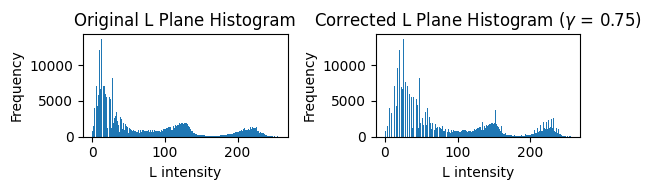

In [25]:
plt.figure(figsize=(6, 2))# Histograms of L plane before and after gamma correction
plt.subplot(1, 2, 1)# Original L plane histogram
plt.hist(L.ravel(),bins=256,range=(0, 256))
plt.xlabel("L intensity")
plt.ylabel("Frequency")
plt.title("Original L Plane Histogram")
plt.subplot(1, 2, 2)# L plane histogram after gamma correction
plt.hist(L_corrected.ravel(),bins=256,range=(0, 256))
plt.xlabel("L intensity")
plt.ylabel("Frequency")
plt.title(f"Corrected L Plane Histogram ($\\gamma$ = {gamma})")
plt.tight_layout()
plt.show()

### Question 4

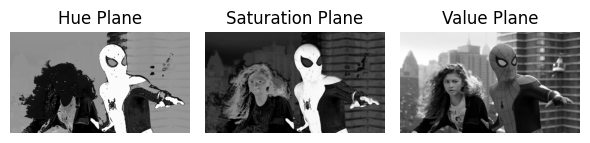

In [26]:
peter = cv.imread('images/peter.png')# Import image
assert peter is not None
peter_hsv = cv.cvtColor(peter, cv.COLOR_BGR2HSV)
peter_rgb = cv.cvtColor(peter, cv.COLOR_BGR2RGB)
H, S, V = cv.split(peter_hsv)# Split into planes
fig, axs = plt.subplots(1, 3, figsize=(6, 2))# Display the planes
axs[0].imshow(H, cmap='gray')
axs[0].set_title('Hue Plane')
axs[0].axis('off')
axs[1].imshow(S, cmap='gray')
axs[1].set_title('Saturation Plane')
axs[1].axis('off')
axs[2].imshow(V, cmap='gray')
axs[2].set_title('Value Plane')
axs[2].axis('off')
plt.tight_layout()
plt.show()

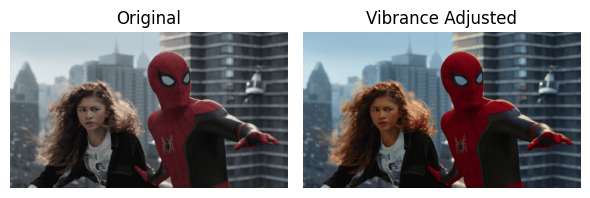

In [36]:
a = 0.7
sigma = 70.0 # Define the transformation function
x = np.arange(0, 256)
f = np.minimum(x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)), 255).astype('uint8')
S_modified = cv.LUT(S, f)# Apply transformation to Saturation plane
merged = cv.merge([H, S_modified, V])# Merge H, modified S, and V planes
peter_modified = cv.cvtColor(merged, cv.COLOR_HSV2RGB)# Convert HSV to RGB
fig, axs = plt.subplots(1, 2, figsize=(6, 2))# Create a figure and axes
axs[0].imshow(peter_rgb)# Original image
axs[0].set_title('Original')
axs[0].axis('off')
axs[1].imshow(peter_modified)# Saturation-adjusted image
axs[1].set_title('Vibrance Adjusted')
axs[1].axis('off')
plt.tight_layout()
plt.show()

By fine-tuning the parameter a, several values were tested to obtain a visually pleasing output. After comparing the resulting images, a = 0.6 was selected as the best value. This value provided an appropriate enhancement of the image saturation while maintaining a natural appearance.

### Question 5

In [38]:
beans = cv.imread('images/beans.png', cv.IMREAD_GRAYSCALE)# Import Shells image
assert beans is not None
def histogram_equalization(f):
    L = 256
    M, N = f.shape
    hist = cv.calcHist([f], [0], None, [L], [0, L])
    cdf = hist.cumsum()
    t = np.array([(L-1)/(M*N)*cdf[k] for k in range(256)]).astype("uint8") # Define transformation
    return t[f]

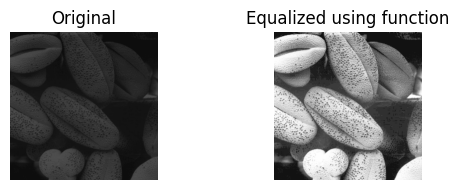

In [39]:
equalized = histogram_equalization(beans)# Do histrogram equalization
fig, ax = plt.subplots(1, 2, figsize=(6, 2))
ax[0].imshow(beans, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original')
ax[0].axis("off")
ax[1].imshow(equalized, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Equalized using function')
ax[1].axis("off")
plt.tight_layout()
plt.show()

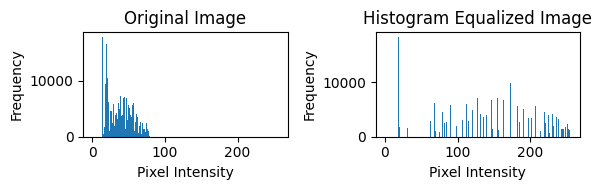

In [40]:
# Display histograms
fig, ax = plt.subplots(1, 2, figsize=(6, 2))
ax[0].hist(beans.ravel(), bins=256, range=(0, 256))
ax[0].set_title('Original Image')
ax[0].set_xlabel('Pixel Intensity')
ax[0].set_ylabel('Frequency')
ax[1].hist(equalized.ravel(), bins=256, range=(0, 256))
ax[1].set_title('Histogram Equalized Image')
ax[1].set_xlabel('Pixel Intensity')
ax[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### Question 6

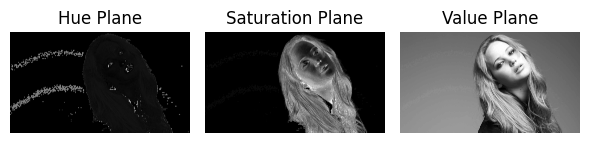

In [41]:
jennifer = cv.imread('images/jennifer.jpeg')# a) Read the image
assert jennifer is not None
hsv = cv.cvtColor(jennifer, cv.COLOR_BGR2HSV)# Convert BGR image to HSV
H, S, V = cv.split(hsv)
plt.figure(figsize=(6, 2))
plt.subplot(1, 3, 1)
plt.imshow(H, cmap='gray' ,vmin=0, vmax=255)
plt.title('Hue Plane')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(S, cmap='gray' ,vmin=0, vmax=255)
plt.title('Saturation Plane')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(V, cmap='gray' ,vmin=0, vmax=255)
plt.title('Value Plane')
plt.axis('off')

plt.tight_layout()
plt.show()

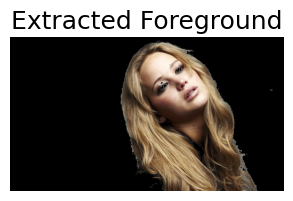

In [42]:
_, mask = cv.threshold(S, 12, 255, cv.THRESH_BINARY)# b) Apply thresholding on Saturation plane
foreground = cv.bitwise_and(jennifer, jennifer, mask=mask)# Use bitwise_and to extract the foreground using the mask
plt.figure(figsize=(6, 2))# Display the extracted foreground
plt.imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
plt.title('Extracted Foreground', fontsize=18)
plt.axis('off')
plt.show()

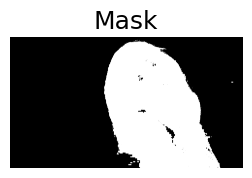

In [44]:
plt.figure(figsize=(3, 2))#c)
plt.imshow(mask, cmap='gray')
plt.title('Mask', fontsize=18)
plt.axis('off')
plt.show()

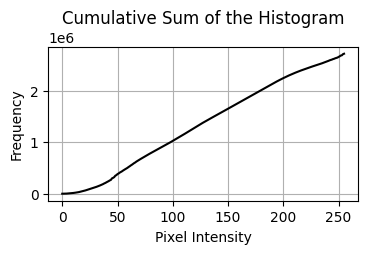

In [45]:
hist = cv.calcHist([V], [0], mask, [256], [0, 256])# d) Calculate the cumulative sum of the histogram
cdf = hist.cumsum()
plt.figure(figsize=(4, 2))
plt.plot(cdf, color='black')
plt.title('Cumulative Sum of the Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

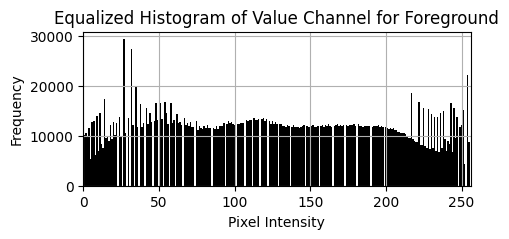

In [46]:
pixels = cdf[-1]# e) Calculate the histogram of the Value channel
t = np.array([(256-1)/(pixels)*cdf[k] for k in range(256)]).astype("uint8")
V_eq = t[V]
hist = cv.calcHist([V_eq], [0], mask, [256], [0, 256])# Calculate the histogram of the equalized Value channel
x_positions = np.arange(len(hist))# Create an array for the x positions of the bars
plt.figure(figsize=(5, 2))
plt.bar(x_positions, hist.flatten(), color='black', width=1) 
plt.title('Equalized Histogram of Value Channel for Foreground')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256]) 
plt.grid(True)
plt.show()

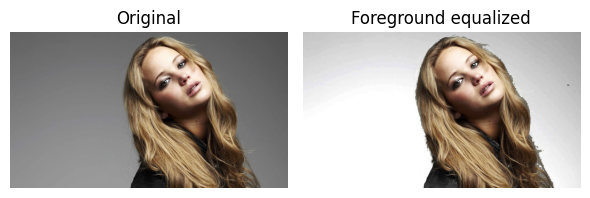

In [48]:
merged = cv.merge([H, S, V])
foreground_modified = cv.cvtColor(merged, cv.COLOR_HSV2RGB)
background = cv.bitwise_and(jennifer, jennifer, mask=cv.bitwise_not(mask))# Extract the background
result = cv.add(cv.cvtColor(background, cv.COLOR_BGR2RGB), foreground_modified)
fig, axs = plt.subplots(1, 2, figsize=(6, 2))# Create a figure and axes
axs[0].imshow(cv.cvtColor(jennifer, cv.COLOR_BGR2RGB))
axs[0].set_title('Original')
axs[0].axis('off') 
axs[1].imshow(result)
axs[1].set_title('Foreground equalized')
axs[1].axis('off') 
plt.tight_layout()
plt.show()

### Question 7

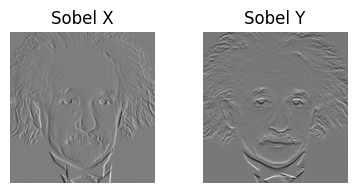

In [50]:
albert = cv.imread('images/albert.png', cv.IMREAD_GRAYSCALE)# Import Einstein image
assert albert is not None
sobel_x = np.array([[1, 0, -1], [2, 0, -2],[1, 0, -1]])# a) Define the Sobel-X filter
sobel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])# Define the Sobel-Y filter
sobel_x_filtered = cv.filter2D(albert, cv.CV_64F, sobel_x)
sobel_y_filtered = cv.filter2D(albert, cv.CV_64F, sobel_y)
plt.figure(figsize=(4, 2))
plt.subplot(1, 2, 1)
plt.imshow(sobel_x_filtered, cmap='gray')
plt.title('Sobel X')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(sobel_y_filtered, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')
plt.tight_layout()
plt.show()

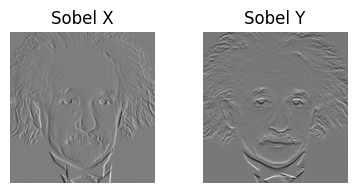

In [51]:
# b)
def apply_filter(image, filter):
    [rows, columns] = np.shape(image)
    filtered_image = np.zeros(shape=(rows, columns))
    for i in range(rows - 2):
        for j in range(columns - 2):
            value = np.sum(np.multiply(filter, image[i:i + 3, j:j + 3]))
            filtered_image[i + 1, j + 1] = value
    return filtered_image
sobel_x = np.array([[1, 0, -1],[2, 0, -2],[1, 0, -1]])
sobel_y = np.array([[1, 2, 1],[0, 0, 0],[-1, -2, -1]])
sobel_x_filtered = cv.filter2D(albert, cv.CV_64F, sobel_x)
sobel_y_filtered = cv.filter2D(albert, cv.CV_64F, sobel_y)
plt.figure(figsize=(4, 2))
plt.subplot(1, 2, 1)
plt.imshow(sobel_x_filtered, cmap='gray')
plt.title('Sobel X')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(sobel_y_filtered, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')
plt.tight_layout()
plt.show()

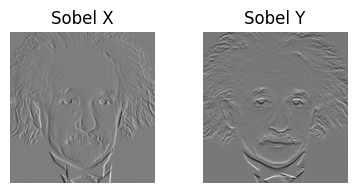

In [53]:
sobel_x_v = np.array([[1], [2], [1]])#c) Separated Sobel filters
sobel_x_h = np.array([[1, 0, -1]])
sobel_y_v = np.array([[1], [0], [-1]])
sobel_y_h = np.array([[1, 2, 1]])
x_filtered = cv.filter2D(cv.filter2D(albert, cv.CV_64F, sobel_x_h),cv.CV_64F, sobel_x_v)
y_filtered = cv.filter2D( cv.filter2D(albert, cv.CV_64F, sobel_y_v),cv.CV_64F, sobel_y_h)
plt.figure(figsize=(4, 2))
plt.subplot(1, 2, 1)
plt.imshow(x_filtered, cmap='gray')
plt.title('Sobel X')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(y_filtered, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')
plt.tight_layout()
plt.show()

## Question 8